# Entendiendo los Métodos de Regularización 

Angélica Mata Zamora

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

In [2]:
import pandas as pd

In [3]:
# Construcción de Variables

x1 = np.arange(-1.3, 3.5, 0.125)

In [4]:
x2 = x1 * x1
x3 = x1 * x1 * x1

In [5]:
w = np.concatenate((np.vstack(x1), np.vstack(x2), np.vstack(x3)), axis=1)

In [6]:
X = pd.DataFrame(w, columns = ['x1','x2','x3'])

In [7]:
X.head

<bound method NDFrame.head of        x1         x2         x3
0  -1.300   1.690000  -2.197000
1  -1.175   1.380625  -1.622234
2  -1.050   1.102500  -1.157625
3  -0.925   0.855625  -0.791453
4  -0.800   0.640000  -0.512000
5  -0.675   0.455625  -0.307547
6  -0.550   0.302500  -0.166375
7  -0.425   0.180625  -0.076766
8  -0.300   0.090000  -0.027000
9  -0.175   0.030625  -0.005359
10 -0.050   0.002500  -0.000125
11  0.075   0.005625   0.000422
12  0.200   0.040000   0.008000
13  0.325   0.105625   0.034328
14  0.450   0.202500   0.091125
15  0.575   0.330625   0.190109
16  0.700   0.490000   0.343000
17  0.825   0.680625   0.561516
18  0.950   0.902500   0.857375
19  1.075   1.155625   1.242297
20  1.200   1.440000   1.728000
21  1.325   1.755625   2.326203
22  1.450   2.102500   3.048625
23  1.575   2.480625   3.906984
24  1.700   2.890000   4.913000
25  1.825   3.330625   6.078391
26  1.950   3.802500   7.414875
27  2.075   4.305625   8.934172
28  2.200   4.840000  10.648000
29  2.325 

In [8]:
# Coeficiente de la función polinómica
w0 = 190
w1 = -85/3
w2 = -165
w3 = 160/3

In [9]:
# Introducir ruido

noise = 200 * (random.random() - 0.5)

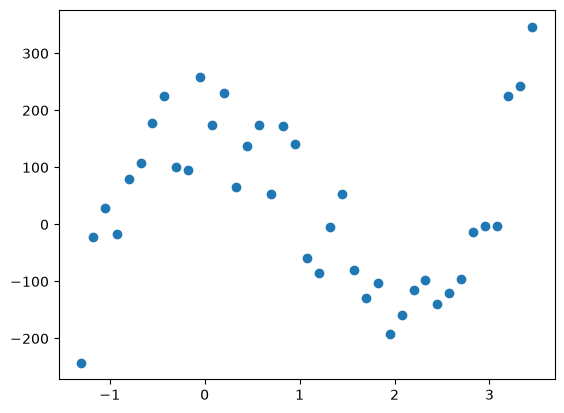

In [10]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:

random.seed(1)
yreal = []
for x in x1:
  noise=200*(random.random() -0.5)
  cc = w3*np.power(x,3) + w2*np.power(x,2) + w1*x + w0 + noise
  yreal.append(cc)
  
  
plt.scatter(x1,yreal)
plt.show()

In [11]:
# Modelos Entrenados
modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30)))
modelos.append(('RIDGE', Ridge(alpha=30)))
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))


In [12]:
yhat0 = [] #RLM
yhat1 = [] #LASSO
yhat2 = [] #RIDGE
yhat12 = [] #ElasticNet

In [13]:
for name, model in modelos:
  # entrenamos el modelo seleccionado y obtenemos sus predicciones:
  print("%s:" % name)
  mm = model.fit(X, np.ravel(yreal))
  yhat = mm.predict(X)
  
  print(mm.intercept_)   # por si deseas conocer w0.
  print(mm.coef_)       # despleguemos los pesos obtenidos

  if name=='LR':
    yhat0.append(yhat)
    print('\n')
  elif name=='LASSO':
    yhat1.append(yhat)
    print('\n')
  elif name=='RIDGE':
    yhat2.append(yhat)
    print('\n')
  else:
    yhat12.append(yhat)

LR:
194.91638384474854
[ -40.14979812 -179.70350006   58.72754395]


LASSO:
117.13069427863503
[  -0.         -102.25253563   31.42721669]


RIDGE:
88.97294849574075
[-27.51573296 -61.84734688  22.38804271]


EN:
105.48167999947962
[-32.10655264 -79.34645456  28.06434904]


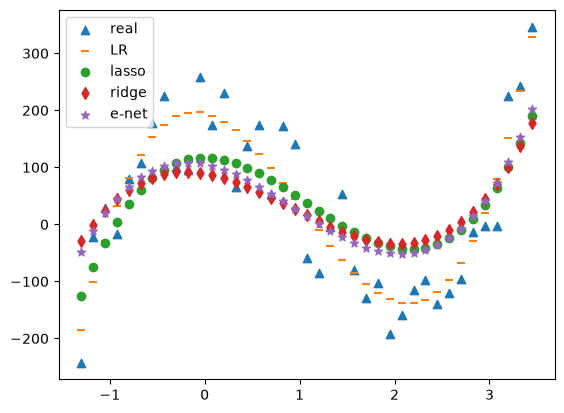

In [ ]:
#Visualicemos Resultados
plt.scatter(x1, np.ravel(yreal), marker='^', label='real')  

plt.scatter(x1, np.ravel(yhat0), marker='_', label='LR')  
plt.scatter(x1, np.ravel(yhat1), marker='o', label='lasso')  
plt.scatter(x1, np.ravel(yhat2), marker='d', label='ridge')  
plt.scatter(x1, np.ravel(yhat12), marker='*', label='e-net')

plt.legend(loc=2)
plt.show()